In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv(r"C:\Users\inter\Desktop\Shrutika\ML Project\Online Retail Store Recomendation (Clustering)\OnlineRetail.csv", encoding='unicode_escape')
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df.dropna(subset=['CustomerID'])

In [6]:
df = df[df['Quantity'] > 0]

In [7]:
df = df[df['UnitPrice'] > 0]

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [11]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [12]:
rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x: (reference_date - x.max()).days,

    'InvoiceNo':'nunique',

    'TotalAmount':'sum'

})

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [13]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [16]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

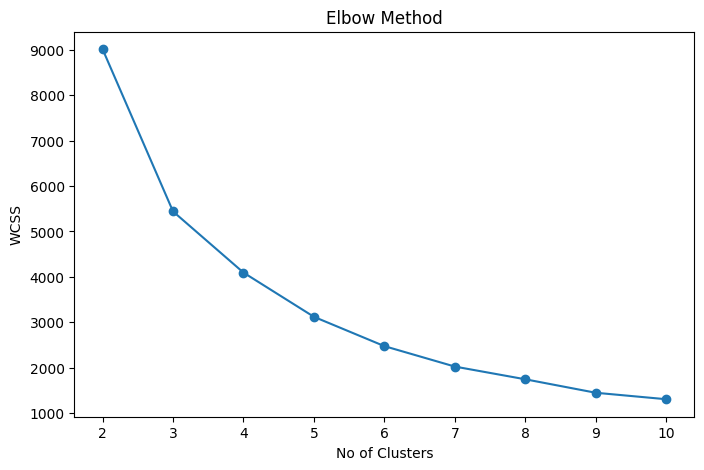

In [17]:
wcss = []

for i in range(2,11):

    model = KMeans(n_clusters=i,
                   random_state=42,
                   n_init=10)

    model.fit(rfm_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11),wcss,marker='o')
plt.xlabel("No of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [31]:
for i in range(2,11):

    model = KMeans(n_clusters=i,
                   random_state=42,
                   n_init=10)

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled,labels)
   
    print(f"{i} Clusters : {score:.3f}")

2 Clusters : 0.896
3 Clusters : 0.594
4 Clusters : 0.616
5 Clusters : 0.617
6 Clusters : 0.596
7 Clusters : 0.516
8 Clusters : 0.517
9 Clusters : 0.478
10 Clusters : 0.427


In [34]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [35]:
print(rfm['Cluster'].value_counts())

Cluster
0    4312
1      26
Name: count, dtype: int64


In [36]:
cluster_summary = rfm.groupby('Cluster').mean()

print(cluster_summary)

           Recency  Frequency      Monetary
Cluster                                    
0        93.057978   3.897263   1548.676893
1         6.038462  66.423077  85904.351538


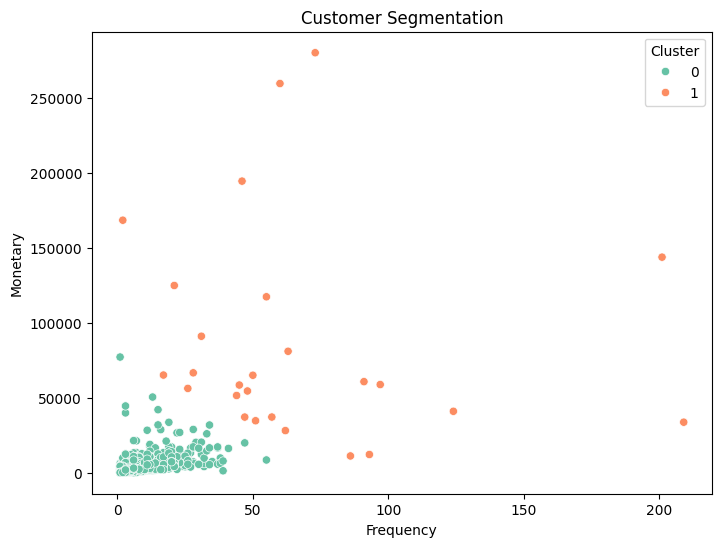

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='Set2'
)

plt.title("Customer Segmentation")
plt.show()

In [24]:
rfm.to_csv("rfm_dataset.csv")

In [26]:
import pickle

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

print("kmeans_model.pkl saved successfully.")

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("scaler.pkl saved successfully.")

kmeans_model.pkl saved successfully.
scaler.pkl saved successfully.


In [27]:
import pickle
import numpy as np

# -------------------------------
# Load Pickle Files
# -------------------------------
with open(r"C:\Users\inter\Desktop\Shrutika\ML Project\Online Retail Store Recomendation (Clustering)\kmeans_model.pkl", "rb") as f:
    kmeans = pickle.load(f)

with open(r"C:\Users\inter\Desktop\Shrutika\ML Project\Online Retail Store Recomendation (Clustering)\scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# -------------------------------
# Customer Data
# -------------------------------
recency = 20
frequency = 15
monetary = 5000

# Convert into array
new_customer = np.array([[recency, frequency, monetary]])

# Scale the data
new_customer_scaled = scaler.transform(new_customer)

# Predict Cluster
cluster = kmeans.predict(new_customer_scaled)

print("Predicted Cluster:", cluster[0])

Predicted Cluster: 0


c:\Users\inter\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
